In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matplotlib.font_manager import FontProperties
font_path = "/mnt/nas2/home/genghaoyu/tools/fonts/Helvetica.ttc"  # 替换为Helvetica字体的路径
helvetica_bold = FontProperties(fname=font_path, weight='bold',size=20)

In [3]:
prob_name = "knapsack-energy"
mse_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob_name}/mse/curve/train_logs.csv")
spo_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob_name}/spo/curve/train_logs.csv")
bb_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob_name}/blackbox/curve-ftn/train_logs.csv")
ltr_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob_name}/listLTR/curve/train_logs.csv")
lodl_log = pd.read_csv(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob_name}/lodl/curve/train_logs.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/knapsack-energy/mse/curve/train_logs.csv'

In [ ]:
mse_log

,epoch,obj,loss,pred_loss,eval
0,Tr-0,597.753540,114737008.0,114737008.0,266.758270
1,Tr-1,618.732849,114344936.0,114344944.0,245.778976
2,Tr-2,635.597046,113942752.0,113942752.0,228.914856
3,Tr-3,644.686401,113529120.0,113529128.0,219.825500
4,Tr-4,652.397034,113102440.0,113102432.0,212.114792
...,...,...,...,...,...
295,Tr-295,799.051392,15921930.0,15921931.0,65.460518
296,Tr-296,799.055725,15916285.0,15916286.0,65.456192
297,Tr-297,799.055725,15910686.0,15910686.0,65.456192
298,Tr-298,799.055725,15905134.0,15905134.0,65.456192


In [4]:
lodl_log

NameError: name 'lodl_log' is not defined

In [5]:
ltr_log

NameError: name 'ltr_log' is not defined

In [6]:
bb_log

NameError: name 'bb_log' is not defined

In [7]:
opt_val = 823.57072/100

import numpy as np
epochs = np.arange(300)
df_pred_loss = pd.DataFrame({ 
                "Epoch":epochs,
                "Two-Stage": mse_log["pred_loss"].values/1e8,
                "BB-FTN": bb_log["pred_loss"].values/5e9,
                "SPO+":spo_log["pred_loss"].values/1e8,
                "LTR": ltr_log["pred_loss"].values/1e8,
                "LODL":lodl_log["pred_loss"].values/1e8,
                })
df_regret = pd.DataFrame({ 
                "Epoch": epochs,
                "Two-Stage": mse_log["eval"].values/opt_val,
                "BB-FTN": bb_log["eval"].values/opt_val,
                "SPO+":spo_log["eval"].values/opt_val,
                "LTR": ltr_log["eval"].values/opt_val,
                "LODL":lodl_log["eval"].values/opt_val,
                })

NameError: name 'mse_log' is not defined

In [8]:
palette = sns.color_palette("deep")
sns.set_style("whitegrid")
# sns.set(font='Helvetica') # 替换'Helvetica'为你想要使用的字体
        # , rc={'axes.labelsize': 16, 'axes.titlesize': 18, 'font.size': 14, 'font.weight': 'bold'})

plt.figure()
metric_name="Pred Loss"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method", palette = palette, data=pd.melt(df_pred_loss, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold') 
plt.ylabel("Prediction Loss (10^8)",fontsize=20,fontweight='bold') 
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
# plt.tick_params(labelsize=15)
legend_font = {
    # 'family': 'Arial',  # 字体
    'style': 'normal',
    'size': 18,  # 字号
    'weight': "bold",  # 是否加粗，不加粗
}
plt.legend(fontsize=18, prop=legend_font)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/curve_pred.pdf',facecolor="w")

NameError: name 'df_pred_loss' is not defined

<Figure size 640x480 with 0 Axes>

In [9]:
palette = sns.color_palette("deep")[1:]
sns.set_style("whitegrid")

plt.figure()
metric_name="Regret"
sns.lineplot(x = "Epoch", y =metric_name , hue="Method",palette = palette, data=pd.melt(df_regret, ["Epoch"], value_name=metric_name, var_name='Method'))
plt.xlabel('Train Epochs',fontsize=22,fontweight='bold')
plt.ylabel("Decision Regret (%)",fontsize=20,fontweight='bold')
# plt.tick_params(labelsize=15)
plt.xticks(fontsize=15,fontweight='bold')
plt.yticks(fontsize=15,fontweight='bold')
plt.legend(fontsize=20,prop=legend_font) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/curve_solution.pdf', facecolor="w")

plt.show()

NameError: name 'df_regret' is not defined

<Figure size 640x480 with 0 Axes>

### muiltiple lineplot version

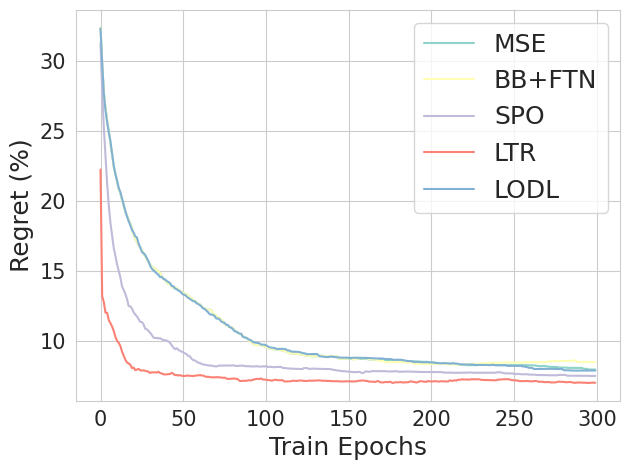

In [16]:
# discarded version
sns.set_style("whitegrid")
opt_val = 823.57072/100
# plt.figure(figsize=(8, 6))
plt.figure()

x_ax = list(range(len(mse_log["eval"].values)))
ax = sns.lineplot(x=x_ax, y=mse_log["eval"].values/opt_val, label="MSE")
ax = sns.lineplot(x=x_ax, y=bb_log["eval"].values/opt_val, label="BB+FTN")
ax = sns.lineplot(x=x_ax, y=spo_log["eval"].values/opt_val, label="SPO")
ax = sns.lineplot(x=x_ax, y=ltr_log["eval"].values/opt_val, label="LTR")
ax = sns.lineplot(x=x_ax, y=lodl_log["eval"].values/opt_val, label="LODL")

plt.xlabel('Train Epochs',fontsize=18) 
plt.ylabel("Regret (%)",fontsize=18) 
plt.tick_params(labelsize=15)
plt.legend(fontsize=18) 
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/curve_solution.pdf', facecolor="w")

plt.show()


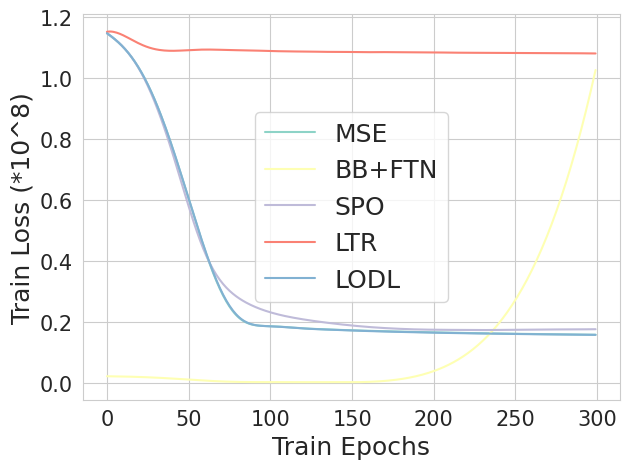

In [12]:
import numpy as np
sns.set_style("whitegrid")

# plt.figure(figsize=(8, 6))
plt.figure()

x_ax = list(range(len(mse_log["pred_loss"].values)))
ax = sns.lineplot(x=x_ax, y=(mse_log["pred_loss"].values/1e8), label="MSE")
ax = sns.lineplot(x=x_ax, y=(bb_log["pred_loss"].values/5e9), label="BB+FTN")
ax = sns.lineplot(x=x_ax, y=(spo_log["pred_loss"].values/1e8), label="SPO")
ax = sns.lineplot(x=x_ax, y=(ltr_log["pred_loss"].values/1e8), label="LTR")
ax = sns.lineplot(x=x_ax, y=(lodl_log["pred_loss"].values/1e8), label="LODL")

plt.xlabel('Train Epochs',fontsize=18) 
plt.ylabel("Train Loss (*10^8)",fontsize=18) 
plt.tick_params(labelsize=15)
plt.legend(fontsize=18)
plt.tight_layout()
plt.savefig(f'/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/curve_pred.pdf',facecolor="w")
plt.show()



In [19]:
id_log

,epoch,obj,loss,pred_loss,eval
0,Tr-0,571.434448,-1.882745e+03,1.147561e+08,293.077423
1,Tr-1,574.971252,-2.557736e+03,1.143861e+08,289.540649
2,Tr-2,581.206787,-3.252171e+03,1.140084e+08,283.305084
3,Tr-3,584.871521,-3.967538e+03,1.136220e+08,279.640350
4,Tr-4,585.342773,-4.705368e+03,1.132258e+08,279.169067
...,...,...,...,...,...
295,Tr-295,668.861572,-1.175368e+07,1.407097e+11,195.650345
296,Tr-296,668.930969,-1.184667e+07,1.430025e+11,195.580887
297,Tr-297,669.267090,-1.194003e+07,1.453233e+11,195.244812
298,Tr-298,669.259583,-1.203376e+07,1.476721e+11,195.252304
